In [11]:
import numpy as np
from pathlib import Path
from typing import Dict, List
import matplotlib.pyplot as plt

from model_ranking import load_h5

In [22]:
def plot_model_scores(
    results: Dict[str, List[float]], 
    target: str, 
    model_names: List[str]
):
    """
    Plots a multi-bar plot for model scores.

    Args:
        results (Dict[str, List[float]]): Dictionary of score names to lists of values.
        target (str): Target dataset name (used for title).
        model_names (List[str]): List of model names (x-axis).
    """
    score_names = list(results.keys())
    n_scores = len(score_names)
    n_models = len(model_names)
    x = np.arange(n_models)
    bar_width = 0.8 / n_scores

    _, ax = plt.subplots(figsize=(10, 6))

    for i, score in enumerate(score_names):
        values = results[score]
        if score == "accuracy_error":
            values = [1 - v for v in values]
            score = "accuracy"
        _ = ax.bar(x + i * bar_width, values, width=bar_width, label=score)

    _ = ax.set_xticks(x + bar_width * (n_scores - 1) / 2)
    _ = ax.set_xticklabels(model_names, rotation=90)
    _ = ax.set_ylabel("Score Value")
    _ = ax.set_title(f"Model Scores for Target: {target}")
    _ = ax.legend(title="Score Type")
    plt.tight_layout()
    plt.show()

In [28]:
models: Dict[str, List[str]] = {
    "EPFL": ["ResNet18_EPFL", "ResNet50_EPFL", "DenseNet121_EPFL", "MobileNetV2_EPFL", "VGG16_EPFL"], #"MobileNetV3_EPFL", "VGG16_EPFL"],
    "Hmito": ["ResNet18_Hmito", "DenseNet121_Hmito", "MobileNetV2_Hmito", "MobileNetV3_Hmito", "VGG16_Hmito"],
    "Rmito": ["ResNet18_Rmito", "MobileNetV2_Rmito", "MobileNetV3_Rmito", "VGG16_Rmito"],
}
sources = ["EPFL", "Hmito", "Rmito"]
targets = ["EPFL", "Hmito", "Rmito"]
base_path = "/g/kreshuk/talks/sampled_features/classification/mitochondria"

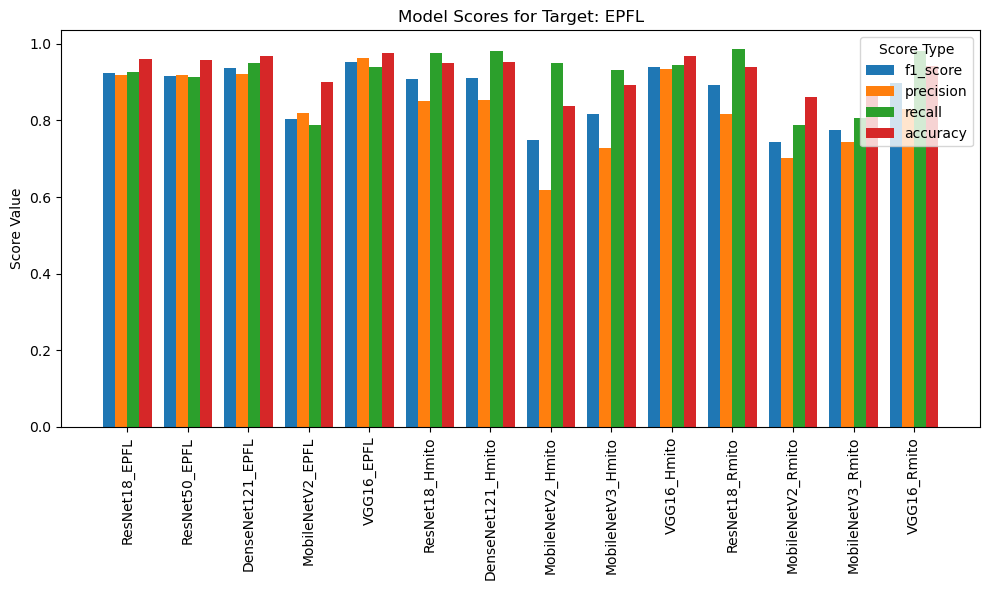

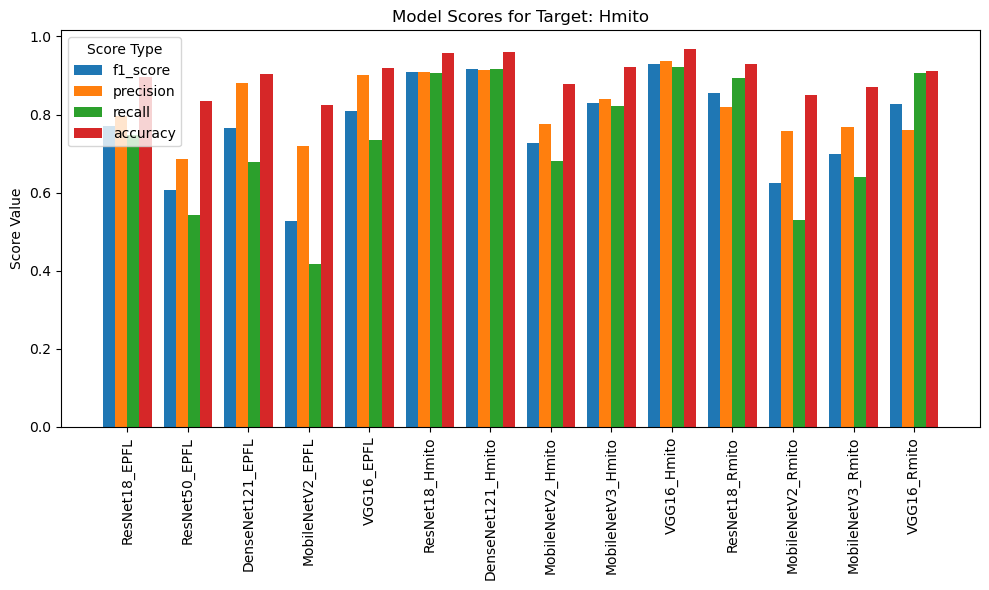

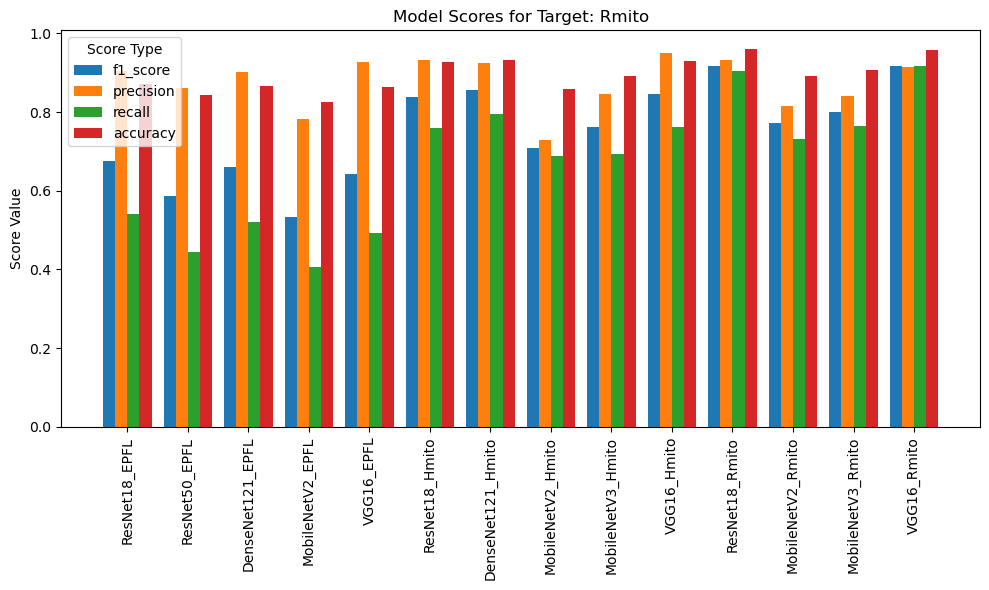

In [29]:
for target in targets:
    f1_scores: List[float] = []
    prec_scores: List[float] = []
    rec_scores: List[float] = []
    acc_err_scores: List[float] = []
    model_names: List[str] = []
    for source in sources:
        for model in models[source]:
            model_names.append(model)
            result_path = Path(base_path) / f"{source}_to_{target}" / model / "None" /"predictions.h5"
            f1_scores.append(float(load_h5(result_path, "f1_score")))
            prec_scores.append(float(load_h5(result_path, "precision")))
            rec_scores.append(float(load_h5(result_path, "recall")))
            acc_err_scores.append(float(load_h5(result_path, "accuracy_error")))

    results = {
        "f1_score": f1_scores,
        "precision": prec_scores,
        "recall": rec_scores,
        "accuracy_error": acc_err_scores,
    }

    plot_model_scores(results, target, model_names)


In [24]:
path = "/g/kreshuk/talks/sampled_features/classification/mitochondria/EPFL_to_EPFL/MobileNetV3_EPFL/None/predictions.h5"
preds = load_h5(path, "predictions")
labels = load_h5(path, "labels")
f1_score = load_h5(path, "f1_score")
prec = load_h5(path, "precision")
rec = load_h5(path, "recall")
acc_err = load_h5(path, "accuracy_error")


In [27]:
unique, count = np.unique(preds, return_counts=True)
dict(zip(unique, count))

{0.44956326: 1280, 0.44956332: 1357, 0.44956338: 2041, 0.4495634: 2}

In [25]:
print(f1_score)
print(prec)
print(rec)
print(acc_err)

0.0
0.0
0.0
0.2564102564102564
